# Spilhaus mesh projection

In [1]:
import pathlib
import platform

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import gmsh
import matplotlib.pyplot as plt
import numpy as np

from graphcast.cli_utils import Configs
from graphcast.geospatial_mesh_utils import CompositeMeshSizeField
from graphcast.geospatial_mesh_utils import read_mesh
from graphcast.gis_utils import equirectangular_srs
from graphcast.mesh_graph import mesh_to_latlon
from graphcast.plot_utils import get_line_collection

In [2]:
save_figures = True

if platform.node().endswith('leonardo.local'):
    data_dir = pathlib.Path("/leonardo_scratch/large/userexternal/scampane/xcast/data")
    configs_dir = pathlib.Path("/leonardo_scratch/fast/userexternal/scampane/xcast/configs")
    output_dir = pathlib.Path("/leonardo_scratch/large/userexternal/scampane/xcast/notebooks/outputs")
else:
    data_dir = pathlib.Path("../data")
    configs_dir = pathlib.Path("../configs")
    output_dir = pathlib.Path("outputs")


In [3]:
gmsh.initialize()
gmsh.option.set_number('General.Verbosity', 3)

In [4]:
# Build mesh size field
mesh_configs_path = configs_dir / "mesh/lambrechts_mini.toml"
mesh_configs = Configs.read(mesh_configs_path)
fields_config = mesh_configs.get("fields", [])
mesh_size = CompositeMeshSizeField(fields_config, prefix=data_dir.parent)

(seamsh) Import features from '../data/geometry/ne_10m_coastline/ne_10m_coastline.shp': 100%|██████████| 4133/4133 [00:00<00:00, 24168.44it/s]
(seamsh) Sampling features for distance computation: 4133it [00:01, 2262.31it/s]


In [5]:
latitudes = np.linspace(90, -90.0, num=721)
latitudes_excluding_south_pole = latitudes[~np.isclose(latitudes, -90.0)]
longitudes = np.linspace(-180, 180, num=1440)
grid_lons, grid_lats = np.meshgrid(longitudes, latitudes_excluding_south_pole, indexing='ij')
grid_lonlats = np.stack([grid_lons.reshape(-1), grid_lats.reshape(-1)], axis=-1)

In [6]:
grid_lonlats

array([[-180.  ,   90.  ],
       [-180.  ,   89.75],
       [-180.  ,   89.5 ],
       ...,
       [ 180.  ,  -89.25],
       [ 180.  ,  -89.5 ],
       [ 180.  ,  -89.75]])

In [7]:
mesh_size_values = mesh_size.mesh_size_3d(grid_lonlats, equirectangular_srs)
mesh_size_values = mesh_size_values.reshape(len(longitudes), len(latitudes_excluding_south_pole))
mesh_size_values = mesh_size_values.transpose()
mesh_size_values

array([[300000.        , 300000.        , 300000.        , ...,
        300000.        , 300000.        , 300000.        ],
       [300000.        , 300000.        , 300000.        , ...,
        300000.        , 300000.        , 300000.        ],
       [300000.        , 300000.        , 300000.        , ...,
        300000.        , 300000.        , 300000.        ],
       ...,
       [287625.1121832 , 287573.73077301, 287522.84117119, ...,
        287729.34429738, 287676.9838721 , 287625.1121832 ],
       [295064.14453262, 295031.64875285, 294999.46879982, ...,
        295130.0802388 , 295096.95530759, 295064.14453262],
       [300000.        , 300000.        , 300000.        , ...,
        300000.        , 300000.        , 300000.        ]])

In [8]:
ocean_mesh, mesh_size_at_nodes = read_mesh(data_dir / 'geometry/lambrechts_mini.msh', "MeshSize")

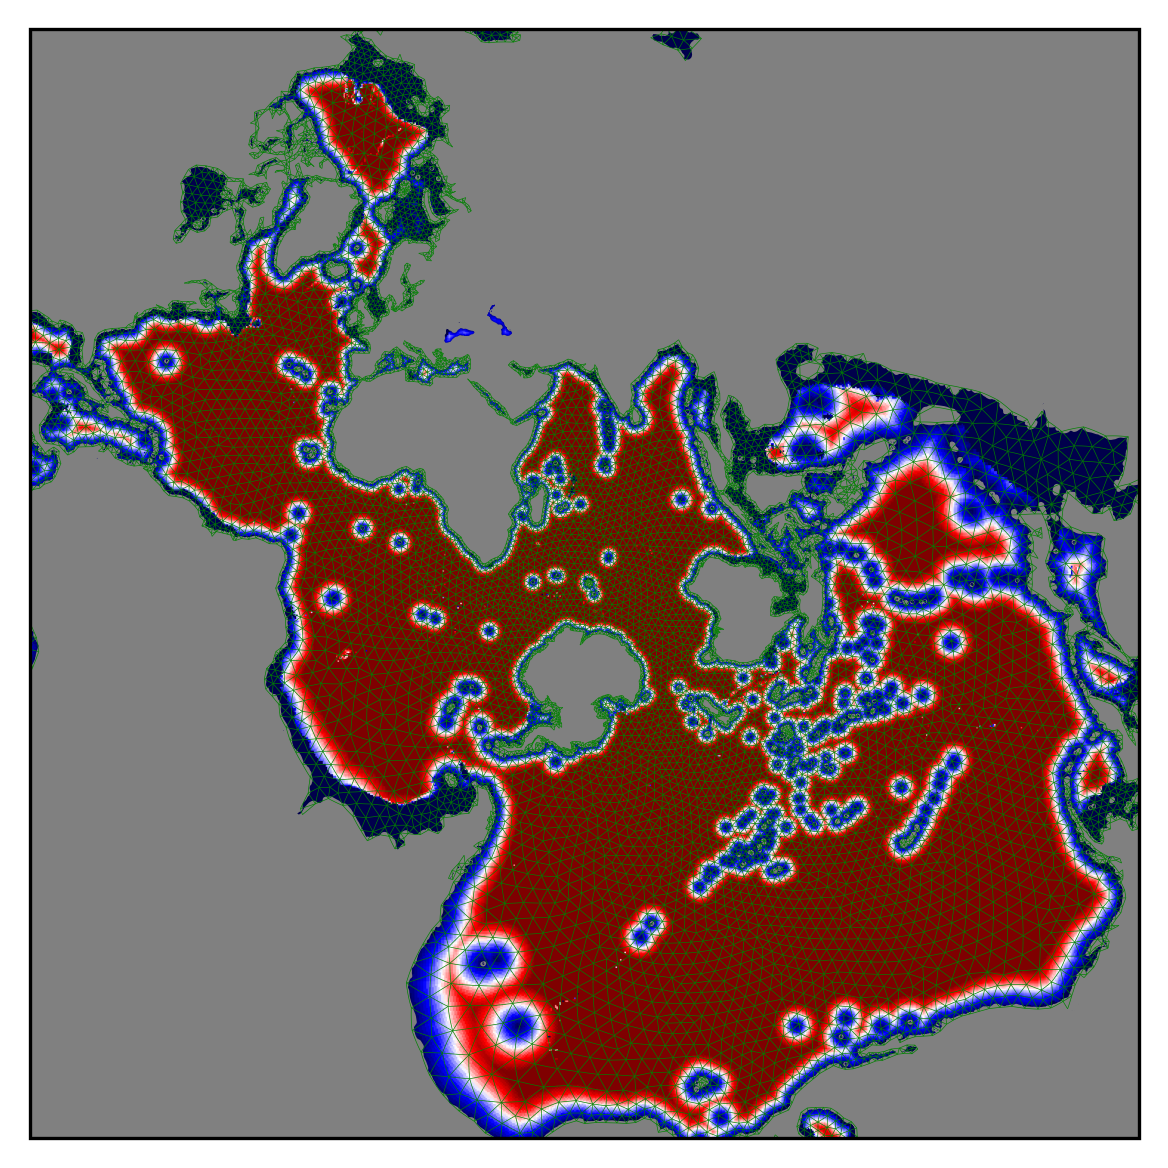

In [9]:
fig = plt.figure(dpi=300)

ax = fig.add_subplot(1, 1, 1, projection=ccrs.Spilhaus())
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='grey'))
mesh_wgs_graph = mesh_to_latlon(ocean_mesh)

latitudes, longitudes = mesh_wgs_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="green", s=2.0, zorder=2, alpha=0.0, transform=ccrs.PlateCarree())
ax.imshow(mesh_size_values, origin='upper', transform=ccrs.PlateCarree(), cmap='seismic')
lc = get_line_collection(mesh_wgs_graph, linewidths=0.16, colors="green", transform=ccrs.Geodetic())
ax.add_collection(lc)

In [10]:
if save_figures:
    fig.savefig(output_dir / "mesh_spilhaus.png")